# Data Notebook
This notebook demonstrates how to fetch historical market capitalization for a set of tickers using the helpers in `qf/core/data.py`, visualize the results, and export them to CSV.

In [2]:
# Imports and setup
import os
import pandas as pd
from datetime import datetime
from qf.core.data import get_historical_market_cap, export_market_cap_to_csv, get_instruments_data, plot_time_series

In [ ]:
# Select sample tickers (S&P 500 list intersect or explicit selection)
try:
    sp = get_instruments_data()
    tickers = sp['symbol'].head(10).tolist()  # take first 10 for demo
except Exception:
    # tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']  # fallback list
    # tickers = ['ATO.PA', '^SBF120', '^FCHI'] 
    tickers = ['SPY']
tickers

['SPY']

In [3]:
# tickers = ['ATO.PA']
tickers = ['SPY']

In [4]:
# Download historical market data (daily OHLCV) for selected tickers
from qf.core.data import get_yahoo_data
import pandas as pd

# Define date range for prices
start_date_prices = '2020-01-01'
end_date_prices = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')

# Single OHLCV field to retrieve
identifier = 'Close'

# Fetch prices using the helper (handles batching)
prices_df = get_yahoo_data(tickers, start_date_prices, end_date_prices, identifier=identifier)


# Preview the first rows
prices_df.head()

[*********************100%***********************]  1 of 1 completed



Ticker,SPY
Date,
2020-01-02,297.699005
2020-01-03,295.444702
2020-01-06,296.571930
2020-01-07,295.737976
2020-01-08,297.314117


hi


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Normalized Closing Prices of Selected Tickers'}, xlabel='Date', ylabel='Value (normalized)'>)

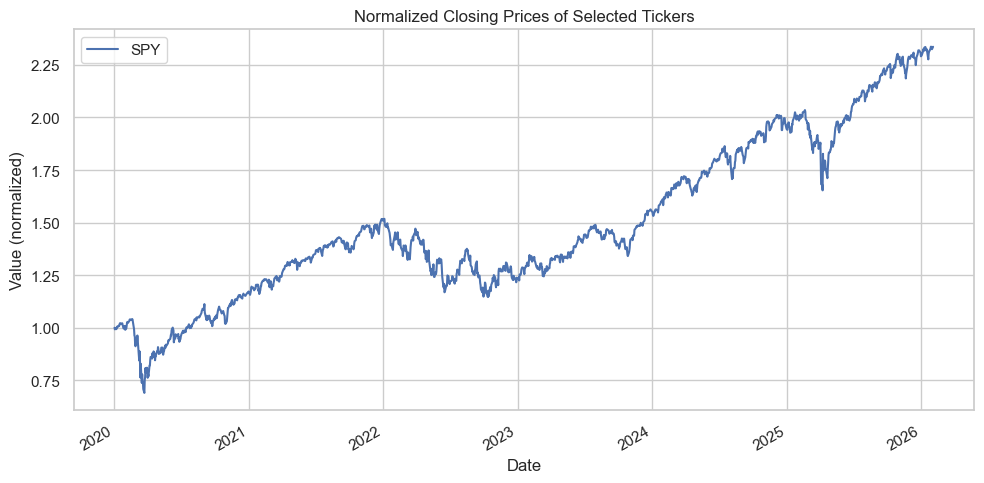

In [9]:
plot_time_series(prices_df, tickers, start_date=start_date_prices, end_date=end_date_prices, normalize=True, log_scale=False, title='Normalized Closing Prices of Selected Tickers')

In [15]:
tickers = ['ATO.PA']
# Fetch historical market cap using price * shares outstanding


In [7]:
# Fetch historical market cap using price * shares outstanding
start_date = '2020-01-01'
end_date = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')
mc_df = get_historical_market_cap(tickers, start_date, end_date)
mc_df.head()

[*********************100%***********************]  1 of 1 completed



,SPY
Date,
2020-01-02,2.732228e+11
2020-01-03,2.711538e+11
2020-01-06,2.721884e+11
2020-01-07,2.714230e+11
2020-01-08,2.728696e+11


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: SPY'}, xlabel='Date', ylabel='Value (normalized)'>)

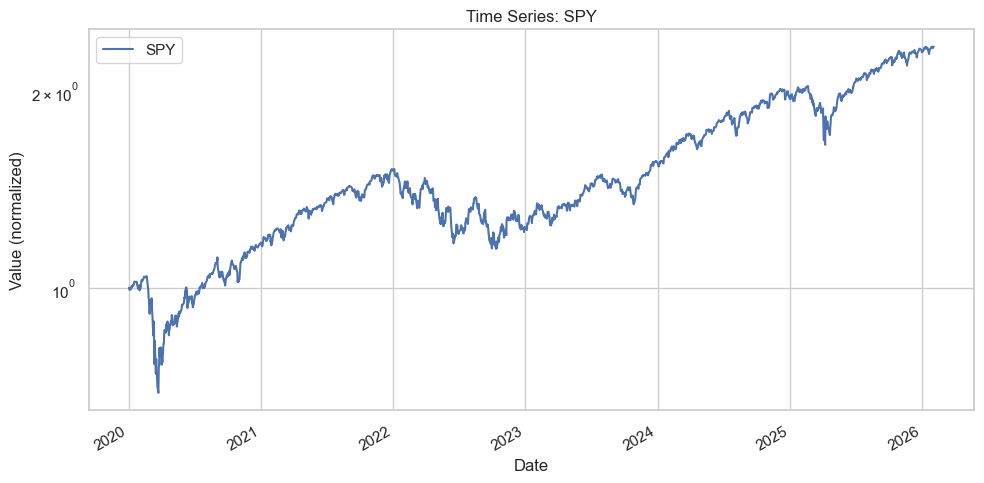

In [8]:
# Plot a few tickers (normalized for comparability)
plot_time_series(mc_df, tickers, start_date=start_date, end_date=end_date, normalize=True, log_scale=True)

# Equal percentage moves look equal: +10% and −10% changes are visually comparable across different price levels.
# Better comparability across assets: If you plot multiple tickers with very different magnitudes (e.g., market caps ranging from millions to hundreds of billions), log scale prevents larger series from visually dominating.
# Compounding-friendly view: Growth trajectories appear as straight(er) lines when growth is roughly constant in percentage terms, making long-run comparison clearer.
# Outlier compression: Very large spikes/drops are compressed, making the rest of the series readable.


Atos SE (ATO.PA) is listed on Euronext Paris and is a component of the SBF 120 index. 
While historically part of the CAC 40, Atos was removed from the benchmark index in 2021 due to a drop in market capitalization. 
Key index associations and classifications:
Primary Index: SBF 120
Sector: Information Technology Services
Market: Euronext Paris (Compartment A) 
As of early 2025, the company is undergoing a restructuring process, including a reverse stock split, but remains listed on the Euronext Paris exchange. 

In [59]:
data_file = 'SBF120.csv'
data_path = './data/'

## check if data directory exists to load data from there
if not os.path.exists(data_path):
    os.makedirs(data_path)

data_file = os.path.join(data_path, data_file)

In [97]:
# Load CSV and parse index with day-first to avoid warnings
_hist_df = pd.read_csv(data_file, index_col=0)
_hist_df.index = pd.to_datetime(_hist_df.index, dayfirst=True)

In [72]:
_hist_df


,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2026-01-30,"6,152.92","6,118.79","6,165.38","6,118.79",97.21M,0.63%
2026-01-29,"6,114.46","6,159.64","6,172.52","6,112.88",95.54M,0.01%
2026-01-28,"6,114.14","6,132.52","6,145.06","6,080.82",89.69M,-0.96%
2026-01-27,"6,173.36","6,165.75","6,186.84","6,146.94",87.34M,0.26%
2026-01-26,"6,157.42","6,159.68","6,178.51","6,138.56",75.07M,-0.17%
...,...,...,...,...,...,...
2016-01-08,"3,431.02","3,481.94","3,508.23","3,431.02",170.99M,-1.45%
2016-01-07,"3,481.47","3,441.83","3,496.78","3,419.94",189.19M,-1.70%
2016-01-06,"3,541.52","3,581.19","3,584.29","3,511.46",146.08M,-1.28%


In [1]:
# Select Price column and rename to ticker, coerce to numeric, clean
hist_prices_df = _hist_df['Price'].to_frame('SBF120')
hist_prices_df['SBF120'] = hist_prices_df['SBF120'].str.replace(',', '').astype(float)

hist_prices_df

NameError: name '_hist_df' is not defined

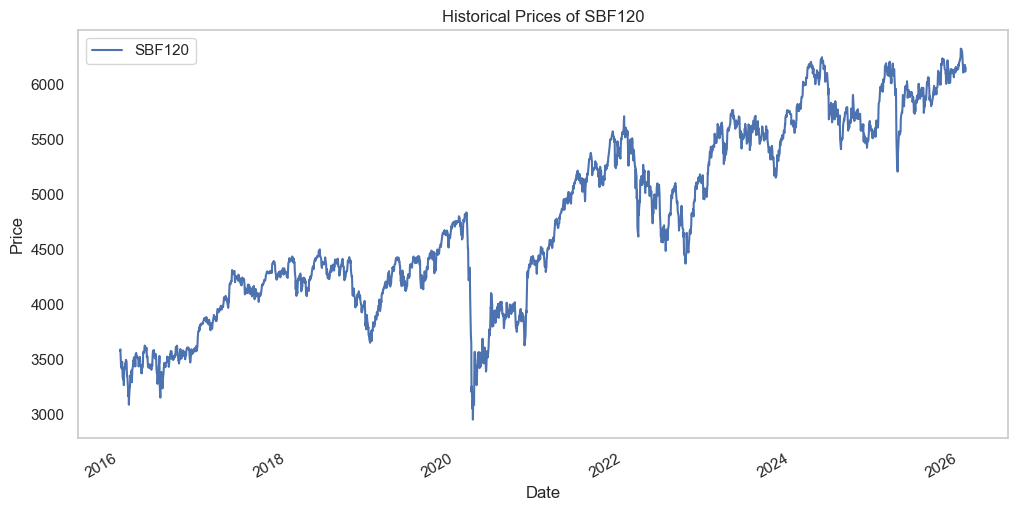

In [107]:
import matplotlib.pyplot as plt

# Plot the historical prices
hist_prices_df.plot(figsize=(12, 6), title="Historical Prices of SBF120", legend=True)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: SBF120'}, xlabel='Date', ylabel='Value'>)

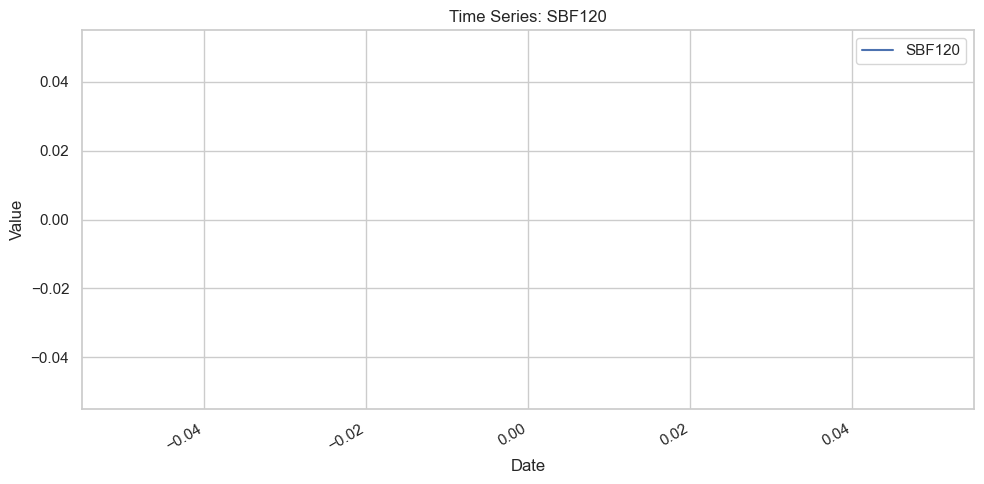

In [108]:
plot_time_series(hist_prices_df, ['SBF120'], start_date=start_date, end_date=end_date, normalize=False, log_scale=False)


In [ ]:
# Select Price column and rename to ticker, coerce to numeric, clean
hist_prices_df = _hist_df['Price'].to_frame('SBF120')
hist_prices_df['SBF120'] = hist_prices_df['SBF120'].str.replace(',', '').astype(float)

# Align tickers list with DataFrame columns for plotting
tickers = hist_prices_df.columns.tolist()

hist_prices_df
